While setting up the single preprocessing pipeline, we're aiming to answer two questions:

== Which preprocessing steps should we keep? (providing the preprocessing pipelines we used when creating the baselines)

side note: [Razzhigaev et al. 2025] (https://arxiv.org/pdf/2502.15007, LLMs tested on reasoning (!!!) tasks) mention that seemingly "minor" tokens like punctuation and determiners store very important contextual information, removing them decreases performance.

== Should we maybe create one "standard" preprocessing step (no stopwords, no punctuation, lowercase etc.) and one "alternative" one and compare them?

Here, I am trying to sum up our discussion on the single preprocessing pipeline, providing two alternative preprocessing functions which are based on baseline preprocessing done by us before.

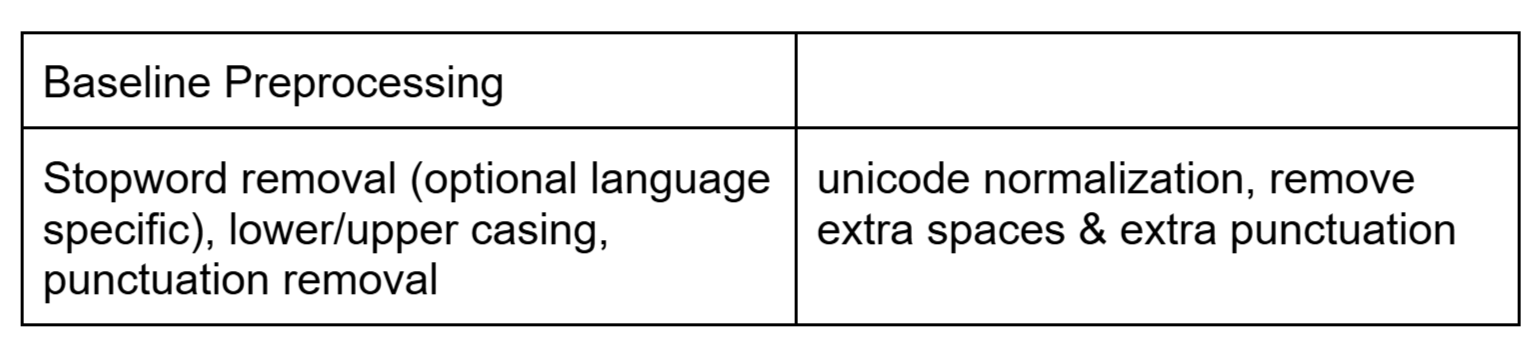

In [7]:
import pandas as pd
import re
import unicodedata

In [8]:
!pip install nltk

In [9]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\white\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
import spacy
import string

stopwords_en = spacy.load("en_core_web_sm")
stopwords_pt = spacy.load("pt_core_news_sm")
english_stopwords = set(stopwords.words('english'))
portuguese_stopwords = set(stopwords.words('portuguese'))

In [27]:
dev_df = pd.read_csv("C:/Users/white/Desktop/ANLP Project/SubTaskA/Data/dev.csv")

In [12]:
dev_df

,ID,Language,MWE,Previous,Target,Next
0,3652,EN,high life,"Does the plumbing predictably rebel, creating ...",Are these interruptions of the good life a nec...,"Not at all , says James von Klemperer, preside..."
1,11103,EN,high life,Let’s be honest – we would be chuffed if our b...,But for Australian fashion designer Abby Kheir...,"Speaking to the Daily Mail , the owner of Abys..."
2,84346,EN,high life,I already have the winning ticket.,"With that, I will be enjoying the pleasures of...","Charles Selle is a former News-Sun reporter, p..."
3,56279,EN,high life,"There were signs everywhere of cosy, comfortab...","Fendi offered swaddling, belted coats resembli...",Shawl collars and enveloping dressing-gown sty...
4,17886,EN,high life,Yet one thing is clear.,"Rick Ross and Diddy exemplify the high life, t...",And who knows -- maybe we'll see Puff on his a...
...,...,...,...,...,...,...
734,95336,PT,papel higiênico,"O presidente da Suzano Papel e Celulose, Walte...",A Suzano Papel e Celulose é uma das 10 maiores...,Vale destacar que a Suzano já recebeu menos en...
735,20353,PT,papel higiênico,"Atualmente, poderiam surgir problemas com carg...","O presidente da Suzano Papel e Celulose, Walte...",A Suzano Papel e Celulose é uma das 10 maiores...
736,54479,PT,papel higiênico,Policiais penais do Complexo Penitenciário Dr ...,O material entorpecente estava escondido em ro...,O flagrante ocorreu na manhã desta sexta-feira...
737,85941,PT,papel higiênico,O acidente ocorreu depois de fortes rajadas de...,"No caso do papel higiênico, a escassez de cont...","Schalka, da Suzano, teme que os problemas logí..."


In [13]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\white\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
import pandas as pd
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [40]:
def basic_preprocessing(df: pd.DataFrame, text_columns: list, lang_column: str) -> pd.DataFrame:
    """
    The first, "basic" text preprocessing function takes the whole dataframe as an input.
    It then converts all the strings of the text to lowercase, removes the punctuation
    and the stopwords (language-specific, but for Galician we use the Portuguese stopwords
    list. The dataframe containing the cleaned text serves as output.
    """
    def define_stopwords(language):
        if language == 'EN':
            return english_stopwords
        elif language in ['PT', 'GL']:  # Treat GL like PT
            return portuguese_stopwords
            
    def clean_text(text, language):        
        text = text.lower()
        text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
        words = word_tokenize(text)

        stopwords = define_stopwords(language)
        
        cleaned_words = [word for word in words if word not in stopwords]
        return " ".join(cleaned_words)
    
    df_cleaned = df.copy()
    
    for col in text_columns:
        df_cleaned[col] = df.apply(lambda row: clean_text(row[col], row[lang_column]), axis=1)
    
    return df_cleaned

df_cleaned = basic_preprocessing(dev_df, text_columns=["Previous", "Target", "Next"], lang_column="Language")

In [41]:
df_cleaned

,ID,Language,MWE,Previous,Target,Next
0,3652,EN,high life,plumbing predictably rebel creating 1000foot c...,interruptions good life necessary condition hi...,says james von klemperer president architectur...
1,11103,EN,high life,let ’ honest – would chuffed bosses gave us bo...,australian fashion designer abby kheir theres ...,speaking daily mail owner abyss abby explained...
2,84346,EN,high life,already winning ticket,enjoying pleasures high life knowing earned mo...,charles selle former newssun reporter politica...
3,56279,EN,high life,signs everywhere cosy comfortable indoorwear l...,fendi offered swaddling belted coats resemblin...,shawl collars enveloping dressinggown styles a...
4,17886,EN,high life,yet one thing clear,rick ross diddy exemplify high life two bosses...,knows maybe well see puff adlib game rick ross...
...,...,...,...,...,...,...
734,95336,PT,papel higiênico,presidente suzano papel celulose walter schalk...,suzano papel celulose 10 maiores produtoras ce...,vale destacar suzano recebeu menos entregas ma...
735,20353,PT,papel higiênico,atualmente poderiam surgir problemas cargas ou...,presidente suzano papel celulose walter schalk...,suzano papel celulose 10 maiores produtoras ce...
736,54479,PT,papel higiênico,policiais penais complexo penitenciário dr man...,material entorpecente escondido rolos papel hi...,flagrante ocorreu manhã desta sextafeira 16
737,85941,PT,papel higiênico,acidente ocorreu fortes rajadas vento,caso papel higiênico escassez contêineres afet...,schalka suzano teme problemas logísticos virem...


In [42]:
def alternative_preprocessing(text):

    """
    The 'alternative' text preprocessing function takes a text as an input,
    takes care of NaN values, normalizes the Unicode characters,
    removes double punctuation but keeps all the other punctuation marks.
    The cleaned text serves as output.
    """

    if pd.isna(text):
        return ""  # take care of NaN

    # Normalize Unicode characters
    text = unicodedata.normalize("NFKC", text)

    # Remove extra spaces but keep single spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Keep punctuation intact (remove punctuation duplicates)
    text = re.sub(r"([!?.]){2,}", r"\1", text)  

    return text

for col in ["Previous", "Target", "Next"]:
    dev_df[col] = dev_df[col].apply(alternative_preprocessing)

In [17]:
dev_df

,ID,Language,MWE,Previous,Target,Next
0,3652,EN,high life,"Does the plumbing predictably rebel, creating ...",Are these interruptions of the good life a nec...,"Not at all , says James von Klemperer, preside..."
1,11103,EN,high life,Let’s be honest – we would be chuffed if our b...,But for Australian fashion designer Abby Kheir...,"Speaking to the Daily Mail , the owner of Abys..."
2,84346,EN,high life,I already have the winning ticket.,"With that, I will be enjoying the pleasures of...","Charles Selle is a former News-Sun reporter, p..."
3,56279,EN,high life,"There were signs everywhere of cosy, comfortab...","Fendi offered swaddling, belted coats resembli...",Shawl collars and enveloping dressing-gown sty...
4,17886,EN,high life,Yet one thing is clear.,"Rick Ross and Diddy exemplify the high life, t...",And who knows -- maybe we'll see Puff on his a...
...,...,...,...,...,...,...
734,95336,PT,papel higiênico,"O presidente da Suzano Papel e Celulose, Walte...",A Suzano Papel e Celulose é uma das 10 maiores...,Vale destacar que a Suzano já recebeu menos en...
735,20353,PT,papel higiênico,"Atualmente, poderiam surgir problemas com carg...","O presidente da Suzano Papel e Celulose, Walte...",A Suzano Papel e Celulose é uma das 10 maiores...
736,54479,PT,papel higiênico,Policiais penais do Complexo Penitenciário Dr ...,O material entorpecente estava escondido em ro...,O flagrante ocorreu na manhã desta sexta-feira...
737,85941,PT,papel higiênico,O acidente ocorreu depois de fortes rajadas de...,"No caso do papel higiênico, a escassez de cont...","Schalka, da Suzano, teme que os problemas logí..."


We will further use these two functions for text preprocessing and further evaluate the results.